<div dir="rtl">

# راهنمای تمرین: کتابخانه OpenCV (OpenCV Library)

این فایل یک راهنمای گام‌به‌گام است. به جای کد آماده، توضیح داده می‌شود که چه کدی باید بنویسید. هر بخش را بخوانید و کد مورد نظر را خودتان در سلول‌های خالی بنویسید.

</div>


<div dir="rtl">

## گام ۱: نصب کتابخانه‌های مورد نیاز (Required Libraries)

در یک سلول کد، دستور نصب کتابخانه‌های زیر را بنویسید:

- `opencv-python-headless` برای OpenCV
- `matplotlib` برای رسم تصویر
- `pillow` برای کار با تصاویر
- `numpy` برای کار با آرایه‌ها

از دستور `!pip install` استفاده کنید و نام همه کتابخانه‌ها را با فاصله جدا کنید.

</div>


In [1]:
# دستور نصب کتابخانه‌ها را اینجا بنویسید


!pip install opencv-python-headless matplotlib pillow numpy


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<div dir="rtl">

## گام ۲: دانلود تصاویر ورودی از گیت‌هاب

در یک سلول کد:

1. یک متغیر به نام `GITHUB_BASE` تعریف کنید و آدرس مخزن گیت‌هاب را در آن قرار دهید: `https://raw.githubusercontent.com/amira133/cv-course-summer-2026/main/images`
2. با استفاده از ماژول `urllib.request` (که روی همه سیستم‌عامل‌ها از جمله ویندوز کار می‌کند)، تصاویر زیر را دانلود کنید:
   - `lenna.jpg`
   - `baboon.png`
   - `barbara.png`
   - `im1.jpg`
   - `im2.jpg`
   - `im3.jpg`
   - `im4.jpg`
   - `im5.jpg`

برای هر تصویر از `urllib.request.urlretrieve(f"{GITHUB_BASE}/نام_فایل", نام_فایل)` استفاده کنید.

</div>


In [3]:
import urllib.request
import urllib.error

# این آدرس پایه کاملا درست است
GITHUB_BASE = "https://raw.githubusercontent.com/amira133/cv-course-summer-2026/main/images"

# پسوند lenna (و احتمالا بقیه) را به jpg تغییر دادیم
image_names = [
    "lenna.jpg", "baboon.png", "barbara.png",
    "im1.jpg", "im2.jpg", "im3.jpg", "im4.jpg", "im5.jpg"
]

for name in image_names:
    url = f"{GITHUB_BASE}/{name}"
    urllib.request.urlretrieve(url, name)
    print(f"✅ {name} با موفقیت دانلود شد.")


✅ lenna.jpg با موفقیت دانلود شد.
✅ baboon.png با موفقیت دانلود شد.
✅ barbara.png با موفقیت دانلود شد.
✅ im1.jpg با موفقیت دانلود شد.
✅ im2.jpg با موفقیت دانلود شد.
✅ im3.jpg با موفقیت دانلود شد.
✅ im4.jpg با موفقیت دانلود شد.
✅ im5.jpg با موفقیت دانلود شد.


<div dir="rtl">

## گام ۳: تعریف تابع کمکی (Helper Function)

یک تابع به نام `get_concat_h` تعریف کنید که دو تصویر را کنار هم قرار دهد:

- ورودی: دو تصویر `im1` و `im2`
- یک تصویر جدید با عرض مجموع دو تصویر و ارتفاع برابر با ارتفاع تصویر اول بسازید (از `Image.new` استفاده کنید)
- تصویر اول را در موقعیت `(0, 0)` قرار دهید
- تصویر دوم را در موقعیت `(im1.width, 0)` قرار دهید
- تصویر نهایی را برگردانید

</div>


In [ ]:
def get_concat_h(im1, im2):
    #https://note.nkmk.me/en/python-pillow-concat-images/
    dst = Image.new('RGB', (im1.width + im2.width, im1.height))
    dst.paste(im1, (0, 0))
    dst.paste(im2, (im1.width, 0))
    return dst

<div dir="rtl">

## گام ۴: فایل‌های تصویر و مسیرها (Image Files and Paths)

### ۴.۱ تعریف نام فایل

یک متغیر به نام `my_image` تعریف کنید و مقدار آن را `"im1.jpg"` قرار دهید.

</div>


In [4]:
# کد ۴.۱ را اینجا بنویسید
my_image = "im1.jpg"

<div dir="rtl">

### ۴.۲ دریافت مسیر پوشه کاری

ماژول `os` را import کنید و با استفاده از تابع `os.getcwd()` مسیر پوشه کاری فعلی را در متغیر `cwd` ذخیره کنید.

</div>


In [5]:
# کد ۴.۲ را اینجا بنویسید

import os
cwd = os.getcwd()
cwd

'd:\\Data\\MyWork\\python\\visionCourse\\Section1\\Session1'

<div dir="rtl">

### ۴.۳ ساخت مسیر کامل تصویر

با استفاده از `os.path.join(cwd, my_image)` مسیر کامل تصویر را در متغیر `image_path` ذخیره کنید.

</div>


In [6]:
# کد ۴.۳ را اینجا بنویسید

image_path = os.path.join(cwd,my_image)

image_path

'd:\\Data\\MyWork\\python\\visionCourse\\Section1\\Session1\\im1.jpg'

<div dir="rtl">

## گام ۵: بارگذاری تصویر در پایتون (Load in Image in Python)

### ۵.۱ import کردن OpenCV

کتابخانه `cv2` را import کنید.

</div>


In [7]:
import cv2

<div dir="rtl">

### ۵.۲ بارگذاری تصویر

با استفاده از تابع `cv2.imread(image_path)` تصویر را در متغیر `image` بارگذاری کنید.

</div>


image = cv2.imread(image_path)

In [8]:
# کد ۵.۲ را اینجا بنویسید

image = cv2.imread(image_path)

<div dir="rtl">

### ۵.۳ بررسی نوع داده

با استفاده از تابع `type()` نوع داده متغیر `image` را بررسی کنید. انتظار می‌رود یک آرایه numpy باشد. سپس خود متغیر `image` را نمایش دهید.

</div>


In [ ]:
# کد ۵.۳ را اینجا بنویسید


type(image)

image

<div dir="rtl">

### ۵.۴ بررسی شکل آرایه

با استفاده از ویژگی `shape` ابعاد تصویر را بررسی کنید. توجه کنید OpenCV در قالب BGR برمی‌گرداند.

</div>


In [11]:
# کد ۵.۴ را اینجا بنویسید

image.shape

(1002, 564, 3)

<div dir="rtl">

### ۵.۵ بررسی مقادیر شدت

با استفاده از متدهای `max()` و `min()` حداکثر و حداقل مقادیر شدت تصویر را به دست آورید.

</div>


In [15]:
# کد ۵.۵ را اینجا بنویسید
image.max()
image.min()

np.uint8(0)

<div dir="rtl">

## گام ۶: رسم تصویر (Plotting an Image)

### ۶.۱ import کردن matplotlib

کتابخانه `matplotlib.pyplot` را با نام مستعار `plt` import کنید.

</div>


In [17]:
# کد ۶.۱ را اینجا بنویسید

import matplotlib.pyplot as plt

<div dir="rtl">

### ۶.۲ رسم تصویر

با استفاده از `plt.figure(figsize=(10,10))` اندازه شکل را تنظیم کنید و سپس با `plt.imshow(image)` تصویر را رسم کنید و با `plt.show()` نمایش دهید.

</div>


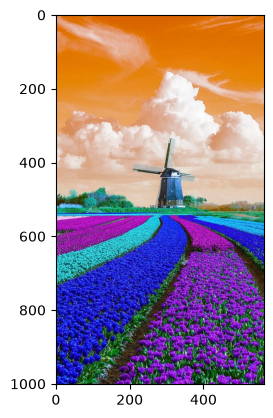

In [18]:
# کد ۶.۲ را اینجا بنویسید

plt.Figure(figsize=(10,10))
plt.imshow(image)
plt.show()

<div dir="rtl">

### ۶.۳ تبدیل فضای رنگی

چون OpenCV در قالب BGR است، با استفاده از `cv2.cvtColor(image, cv2.COLOR_BGR2RGB)` تصویر را به قالب RGB تبدیل کنید و در متغیر `new_image` ذخیره کنید. سپس دوباره رسم کنید.

</div>


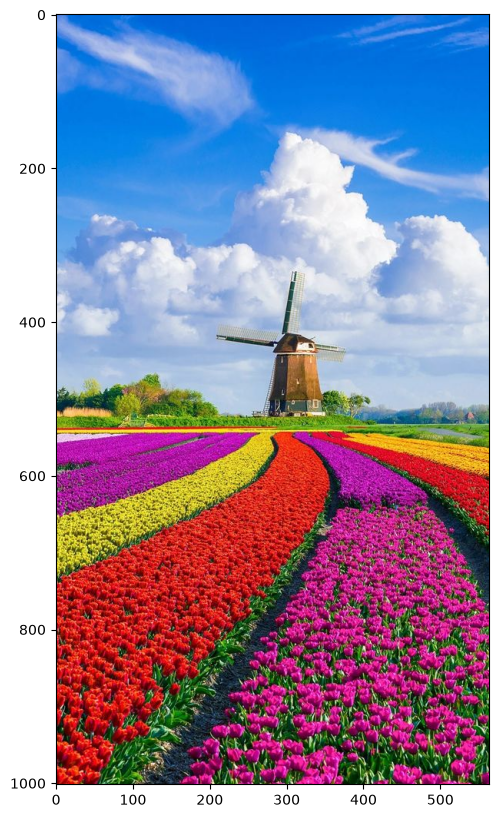

In [21]:
# کد ۶.۳ را اینجا بنویسید


new_image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,10))
plt.imshow(new_image)
plt.show()

<div dir="rtl">

### ۶.۴ بارگذاری مجدد با مسیر

تصویر را دوباره با `cv2.imread(image_path)` بارگذاری کنید و شکل آن را نمایش دهید.

</div>


In [22]:
# کد ۶.۴ را اینجا بنویسید

image = cv2.imread(image_path)
image.shape


(1002, 564, 3)

<div dir="rtl">

### ۶.۵ ذخیره تصویر

با استفاده از `cv2.imwrite("images/im1.png", new_image)` تصویر را ذخیره کنید.

</div>


In [24]:
# کد ۶.۵ را اینجا بنویسید

cv2.imwrite("images/im1.png",new_image)

True

<div dir="rtl">

## گام ۷: تصاویر خاکستری (Grayscale Images)

### ۷.۱ تبدیل به خاکستری

با استفاده از `cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)` تصویر را به خاکستری تبدیل کنید و در متغیر `image_gray` ذخیره کنید.

</div>


In [ ]:
# کد ۷.۱ را اینجا بنویسید

<div dir="rtl">

### ۷.۲ بررسی ابعاد

با ویژگی `shape` بررسی کنید که آرایه فقط دو بعد دارد.

</div>


In [ ]:
# کد ۷.۲ را اینجا بنویسید

<div dir="rtl">

### ۷.۳ رسم تصویر خاکستری

با `plt.imshow(image_gray, cmap='gray')` تصویر خاکستری را رسم کنید.

</div>


In [ ]:
# کد ۷.۳ را اینجا بنویسید

<div dir="rtl">

### ۷.۴ ذخیره تصویر خاکستری

با `cv2.imwrite("images/im1_gray.png", image_gray)` تصویر خاکستری را ذخیره کنید.

</div>


In [ ]:
# کد ۷.۴ را اینجا بنویسید

<div dir="rtl">

### ۷.۵ بارگذاری مستقیم خاکستری

یک متغیر `my_image2` با مقدار `"im2.jpg"` تعریف کنید، مسیر را بسازید و با `cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)` تصویر را مستقیماً خاکستری بارگذاری کنید. سپس شکل آن را بررسی و رسم کنید.

</div>


In [ ]:
# کد ۷.۵ را اینجا بنویسید

<div dir="rtl">

## گام ۸: کانال‌های رنگی (Color Channels)

### ۸.۱ بارگذاری تصویر رنگی

یک متغیر `my_image3` با مقدار `"im3.jpg"` تعریف کنید، مسیر را بسازید و تصویر را در متغیر `img` بارگذاری کنید. سپس با تبدیل BGR به RGB رسم کنید.

</div>


In [ ]:
# کد ۸.۱ را اینجا بنویسید

<div dir="rtl">

### ۸.۲ استخراج کانال‌ها

با استفاده از نمایه‌گذاری آرایه، کانال‌های آبی، سبز و قرمز را به ترتیب در متغیرهای `blue`، `green` و `red` ذخیره کنید:
- کانال آبی: ایندکس ۰
- کانال سبز: ایندکس ۱
- کانال قرمز: ایندکس ۲

</div>


In [ ]:
# کد ۸.۲ را اینجا بنویسید

<div dir="rtl">

### ۸.۳ اتصال کانال‌ها

با استفاده از `cv2.vconcat([blue, green, red])` کانال‌ها را به صورت عمودی به هم متصل کنید و در متغیر `im_bgr` ذخیره کنید.

</div>


In [ ]:
# کد ۸.۳ را اینجا بنویسید

<div dir="rtl">

### ۸.۴ رسم مقایسه‌ای

با `plt.subplot` دو تصویر کنار هم رسم کنید: تصویر رنگی و کانال‌های متصل‌شده با `cmap='gray'`.

</div>


In [ ]:
# کد ۸.۴ را اینجا بنویسید

<div dir="rtl">

## گام ۹: نمایه‌گذاری (Indexing)

### ۹.۱ برش ردیف‌ها

متغیر `rows` را با مقدار `256` تعریف کنید و با `new_image[0:rows,:,:]` نیمه بالایی تصویر را رسم کنید.

</div>


In [ ]:
# کد ۹.۱ را اینجا بنویسید

<div dir="rtl">

### ۹.۲ برش ستون‌ها

متغیر `columns` را با مقدار `256` تعریف کنید و با `new_image[:,0:columns,:]` نیمه اول تصویر را رسم کنید.

</div>


In [ ]:
# کد ۹.۲ را اینجا بنویسید

<div dir="rtl">

### ۹.۳ کپی آرایه

با `new_image.copy()` یک کپی از تصویر در متغیر `A` بسازید و رسم کنید.

</div>


In [ ]:
# کد ۹.۳ را اینجا بنویسید

<div dir="rtl">

### ۹.۴ ارجاع به حافظه

متغیر `B` را برابر `A` قرار دهید، همه مقادیر `A` را صفر کنید و `B` را رسم کنید. مشاهده می‌کنید که `B` هم صفر شده است.

</div>


In [ ]:
# کد ۹.۴ را اینجا بنویسید

<div dir="rtl">

## گام ۱۰: دستکاری کانال‌های رنگی

### ۱۰.۱ تصویر قرمز

یک متغیر `my_img` با مقدار `"im5.jpg"` تعریف کنید، تصویر را در `img` بارگذاری کنید، یک کپی در `img_red` بسازید و کانال‌های آبی (ایندکس ۰) و سبز (ایندکس ۱) را صفر کنید. سپس تصویر را با تبدیل BGR به RGB رسم کنید.

</div>


In [ ]:
# کد ۱۰.۱ را اینجا بنویسید

<div dir="rtl">

### ۱۰.۲ تصویر آبی

یک کپی در `img_blue` بسازید و کانال‌های سبز (ایندکس ۱) و قرمز (ایندکس ۲) را صفر کنید و رسم کنید.

</div>


In [ ]:
# کد ۱۰.۲ را اینجا بنویسید

<div dir="rtl">

### ۱۰.۳ تصویر سبز

یک کپی در `img_green` بسازید و کانال‌های آبی (ایندکس ۰) و قرمز (ایندکس ۲) را صفر کنید و رسم کنید.

</div>


In [ ]:
# کد ۱۰.۳ را اینجا بنویسید

<div dir="rtl">

## گام ۱۱: سوال ۱ (Question 1)

از تصویر `baboon.png` استفاده کنید:

1. تصویر را با `cv2.imread` در متغیر `baboon_blue` بارگذاری کنید.
2. تصویر را با `cv2.cvtColor` از BGR به RGB تبدیل کنید.
3. کانال آبی را صفر کنید (در قالب RGB، کانال آبی ایندکس ۲ است).
4. تصویر را با `plt.imshow` رسم کنید.

</div>


In [ ]:
# راه‌حل سوال ۱ را اینجا بنویسید

<div dir="rtl">

## جمع‌بندی

در این راهنما یاد گرفتید:

- کتابخانه‌های مورد نیاز را نصب کنید
- تصاویر را از گیت‌هاب دانلود کنید
- تصاویر را با OpenCV بارگذاری و رسم کنید
- فضای رنگی BGR را به RGB تبدیل کنید
- تصاویر خاکستری بسازید
- کانال‌های رنگی را استخراج و دستکاری کنید
- از نمایه‌گذاری و کپی آرایه‌ها استفاده کنید

</div>
